# Demand Estimation and Market Analysis: Air Fryers

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

Use `pandas`, `numpy`, `seaborn`, `matplotlib`, and `scikit-learn`. Do **not** use scikit-learn pipelines for this assignment. Use ordinary data frames, `pd.get_dummies`, and `LinearRegression` so that every column in the model is visible and interpretable.

## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

## 1. Data Analysis

Load `air_fryers_clean_brand_year.csv`.

1. Verify that the data contain 10 brands and the years 2019-2023.
2. Check that `brand_share` sums to 1 within each year.
3. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share
4. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?
5. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

This part of the work is the **data analyst** role: making the data trustworthy, visual, and interpretable before building a model.

In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sklearn

In [6]:
#1. Verify that the data contain 10 brands and the years 2019-2023.
df = pd.read_csv('air_fryers_clean_brand_year.csv')
print(f"Number of brands: {len(df['brand'].unique())}")
print(f"Brands: {df['brand'].unique().tolist()}")
print(f"Years: {df['year'].unique().tolist()}")

Number of brands: 10
Brands: ['chefman', 'cosori', 'cuisinart', 'dash', 'gowise usa', 'instant_pot', 'ninja', 'nuwave', 'oster', 'ultrean']
Years: [2019, 2020, 2021, 2022, 2023]


In [7]:
#2. Check that `brand_share` sums to 1 within each year. - verified that they do
print(df.groupby('year')['brand_share'].sum())

year
2019    1.0
2020    1.0
2021    1.0
2022    1.0
2023    1.0
Name: brand_share, dtype: float64


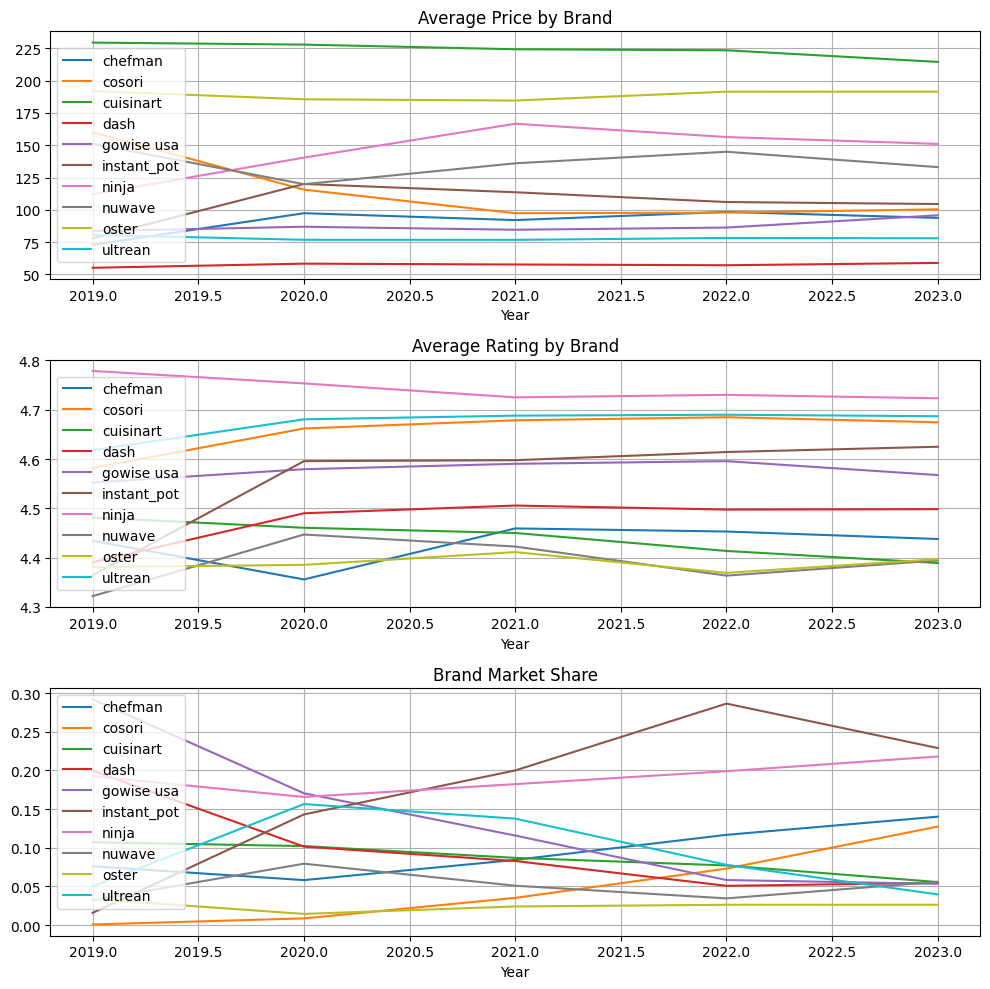

In [8]:
#3. Plot the following over time by brand: average price, average rating, brand market share
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

for brand in df['brand'].unique():
    brand_data = df[df['brand'] == brand]
    axes[0].plot(brand_data['year'], brand_data['avg_price'], label=brand)
    axes[1].plot(brand_data['year'], brand_data['avg_rating'], label=brand)
    axes[2].plot(brand_data['year'], brand_data['brand_share'], label=brand)

axes[0].set_title('Average Price by Brand')
axes[1].set_title('Average Rating by Brand')
axes[2].set_title('Brand Market Share')

for ax in axes:
    ax.set_xlabel('Year')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# 4. Summarize the product characteristics:
# - Which features are common? 
# - Which features are rare?
# - Are there brands that seem to specialize in different product types?

char_cols = ['compact_share', 'dual_basket_share', 'oven_style_share', 'rotisserie_share', 'window_share']

print("Average feature share across all brand-years")
print(df[char_cols].mean().sort_values(ascending=False))

print("\nBrand specialization (mean share per brand)")
print(df.groupby('brand')[char_cols].mean())

Average feature share across all brand-years
compact_share        0.980081
oven_style_share     0.562647
rotisserie_share     0.070762
window_share         0.036741
dual_basket_share    0.002260
dtype: float64

Brand specialization (mean share per brand)
             compact_share  dual_basket_share  oven_style_share  \
brand                                                             
chefman           0.961595           0.013462          0.596962   
cosori            0.996784           0.000000          0.029952   
cuisinart         0.995902           0.000000          0.913059   
dash              0.999481           0.000000          0.890098   
gowise usa        0.999877           0.000000          0.183790   
instant_pot       0.859655           0.000030          0.674784   
ninja             0.992084           0.002488          0.100477   
nuwave            0.995431           0.006622          0.542646   
oster             1.000000           0.000000          0.864518   
ultrean 

## Answer

Compact share & oven style share are the two most common features.
Window share & dual basket share are the two rarest features.
Chefman seems to have all 5 of the included features, giving it the most diversified product mix.
Cosori, Gowise, Nuwave and Ninja seem to specialize in compact share.
Cuisinart, Dash, Oster, Instant pot, and Ultrean specialize in compact and oven-style.

5. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

In the market for air fryers, Cuisinart, Oster, and Ninja are currently the most expensive brands with prices around 150–215 dollars. However, Dash, Ultrean, Chefman and Gowise USA are the least expensive brands with prices below 100 dollars. Instant pot, with a price toward the middle of the pack, has the highest market share today. Ninja, which also has a similarly average price, has the second largest market share. Chefman and Cosori also have fairly large market shares. The market looks unstable over time as share is shifting across brands and there is no single dominant player that holds its position from 2019-2023.

## 2. Demand Estimation

We will estimate a logit-style demand model using linear regression. The model is:

$$
\log(s_{bt}) = \alpha_0 + \alpha_t + \gamma_b + \beta_{price}p_{bt} + \beta_{rating}r_{bt} + \sum_{\ell=1}^L \beta_\ell x_{bt\ell} + \epsilon_{bt}.
$$

Here:

- $b$ indexes brands
- $t$ indexes years
- $s_{bt}$ is `brand_share`
- $p_{bt}$ is `avg_price`
- $r_{bt}$ is `avg_rating`
- $x_{bt\ell}$ are the product characteristics
- $\alpha_t$ are year dummy coefficients
- $\gamma_b$ are brand dummy coefficients
- $\beta_{price}$ is **one constant price coefficient**, shared by all brands and all years

That last point matters: do **not** estimate a different price coefficient for every brand-year. We do not have enough information for that, and it would make the cost calculation impossible to interpret.

Use `pd.get_dummies(..., drop_first=True)` for brand and year dummies. The dropped brand and dropped year become the reference categories, so all dummy coefficients are interpreted relative to those omitted categories.

Questions:

1. What is the estimated price coefficient, $\hat{\beta}_{price}$?
2. Is it negative? Why is that important?
3. Which product features are associated with higher demand?
4. Which brand dummy coefficients are largest? Remember that these are interpreted relative to the dropped brand.
5. Which year dummy coefficients are largest? Remember that these are interpreted relative to the dropped year.
6. What is the model's $R^2$?

This part of the work is the **data scientist** role: turning the cleaned data into a model that can be used for prediction and interpretation.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

char_cols = ['compact_share', 'dual_basket_share', 'oven_style_share', 'rotisserie_share', 'window_share']

year_dummies = pd.get_dummies(df['year'].astype(str), prefix='year', drop_first=True)
brand_dummies = pd.get_dummies(df['brand'], prefix='brand', drop_first=True)

X = pd.concat([df[['avg_price', 'avg_rating'] + char_cols].reset_index(drop=True), year_dummies.reset_index(drop=True), brand_dummies.reset_index(drop=True)], axis=1)
y = df['log_brand_share'].reset_index(drop=True)

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

coef_df = pd.Series(model.coef_, index=X.columns)

print(f"Price coefficient:  {coef_df['avg_price']}")
print(f"Rating coefficient: {coef_df['avg_rating']}")

print("\nProduct characteristics:")
print(coef_df[char_cols])

print("\nBrand dummies")
print(coef_df.filter(like='brand_').sort_values(ascending=False))

print("\nYear dummies")
print(coef_df.filter(like='year_').sort_values(ascending=False))

print(f"\nR² = {r2_score(y, y_pred)}")

Price coefficient:  -0.037667652984293705
Rating coefficient: 0.2875168474327462

Product characteristics:
compact_share         9.815304
dual_basket_share    -9.509686
oven_style_share      1.941774
rotisserie_share     -5.674054
window_share         12.880298
dtype: float64

Brand dummies
brand_cuisinart      6.422436
brand_ninja          5.838705
brand_instant_pot    4.626260
brand_gowise usa     3.938996
brand_oster          3.928074
brand_nuwave         3.544883
brand_cosori         2.551946
brand_ultrean        0.942399
brand_dash           0.176655
dtype: float64

Year dummies
year_2020    0.119071
year_2021    0.041900
year_2023   -0.003307
year_2022   -0.098860
dtype: float64

R² = 0.7634539500914359


1. The estimated price coefficient is around 0.0377.
2. It is negative. This is important because it means that as price increases, on average, the brand has a lower share in the market. 
3. Compact share, oven style share, and window share are all associated with higher demand. 
4. The largest brand dummy coefficients are cuisinart, ninja, and instant pot.
5. The largest year dummy coefficients are 2020 and 2021.
6. The model's $R^2$ is 0.7634.

## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the typical unit costs and markups?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs?
4. Which brands have the highest average markups?
5. Which brands have the highest share-weighted average profit?
6. Make kernel density plots of unit costs, markups, and average profit.
7. Make scatter plots of price vs. unit cost and average rating vs. unit cost.

Finally, compute:

$$
\frac{d\pi_{bt}}{dp_{bt}} = \hat{s}'_{bt}(p_{bt})(p_{bt} - \hat{c}_{bt}) + s_{bt}.
$$

This should be very close to zero **by construction**, because you used the same first-order condition to estimate unit cost. Treat this as a numerical check, not as independent evidence that prices are truly optimal.

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability.

In [12]:
beta_price = coef_df['avg_price']

df['demand_slope'] = beta_price * df['brand_share'] * (1 - df['brand_share'])
df['unit_cost'] = df['avg_price'] + (df['brand_share']/df['demand_slope'])
df['markup'] = df['avg_price'] - df['unit_cost']
df['average_profit'] = df['brand_share'] * df['markup']

# Outputs to answer questions 1 - 5

# 1 - typical unit costs and markups
print("=== Typical unit costs and markups ===")
print(df[['unit_cost', 'markup']].describe().round(2))
# looks like the avg for unit_cost is 93.10, with a min of 22 and a max of 199 (large range) - percentiles in output
# the avg for markup is 29.70, with a min of 26.57 and a max of 37.51 (smaller range). - percentiles in output

# 2 - any negative unit costs?
print("\n=== Negative unit costs ===")
neg = df[df['unit_cost'] < 0]
print(f"Count: {len(neg)}")
if len(neg) > 0:
    print(neg[['brand', 'year', 'unit_cost']])
# no negative unit costs - all inferred costs are positive. if it were negative it would mean the demand model is 
# implies a brand is pricing below its own marginal cost

# 3 - highest average unit costs by brand
print("\n=== Avg unit cost by brand ===")
print(df.groupby('brand')['unit_cost'].mean().sort_values(ascending=False).round(2))
# the brands that have the highest avg unit costs are (top 5 in order) - cuisinart, oster, ninja, nuwave, osori

# 4 - highest average markups by brand
print("\n=== Avg markup by brand ===")
print(df.groupby('brand')['markup'].mean().sort_values(ascending=False).round(2))
# the brands that have the highest avg markups (top 5 in order) - ninja, instant_pot, gowise usa, dash, chefman

# 5 - highest share weighted average profit by brand
print("\n=== Avg share-weighted profit by brand ===")
print(df.groupby('brand')['average_profit'].mean().sort_values(ascending=False).round(4))
# the brands that have the highest share weighted average profit (top 5 in order) - 
# ninja, instant_pot, gowise usa, dash, chefman


=== Typical unit costs and markups ===
       unit_cost  markup
count      50.00   50.00
mean       93.10   29.70
std        51.70    2.62
min        22.00   26.57
25%        53.16   27.95
50%        70.04   28.81
75%       123.56   30.96
max       199.73   37.51

=== Negative unit costs ===
Count: 0

=== Avg unit cost by brand ===
brand
cuisinart      194.90
oster          161.80
ninja          112.49
nuwave         109.05
cosori          86.28
instant_pot     71.90
chefman         61.57
gowise usa      56.30
ultrean         48.79
dash            27.94
Name: unit_cost, dtype: float64

=== Avg markup by brand ===
brand
ninja          32.85
instant_pot    32.56
gowise usa     31.15
dash           29.54
chefman        29.37
ultrean        29.33
cuisinart      29.05
cosori         27.98
nuwave         27.97
oster          27.23
Name: markup, dtype: float64

=== Avg share-weighted profit by brand ===
brand
ninja          6.3061
instant_pot    6.0103
gowise usa     4.6058
dash           2.9

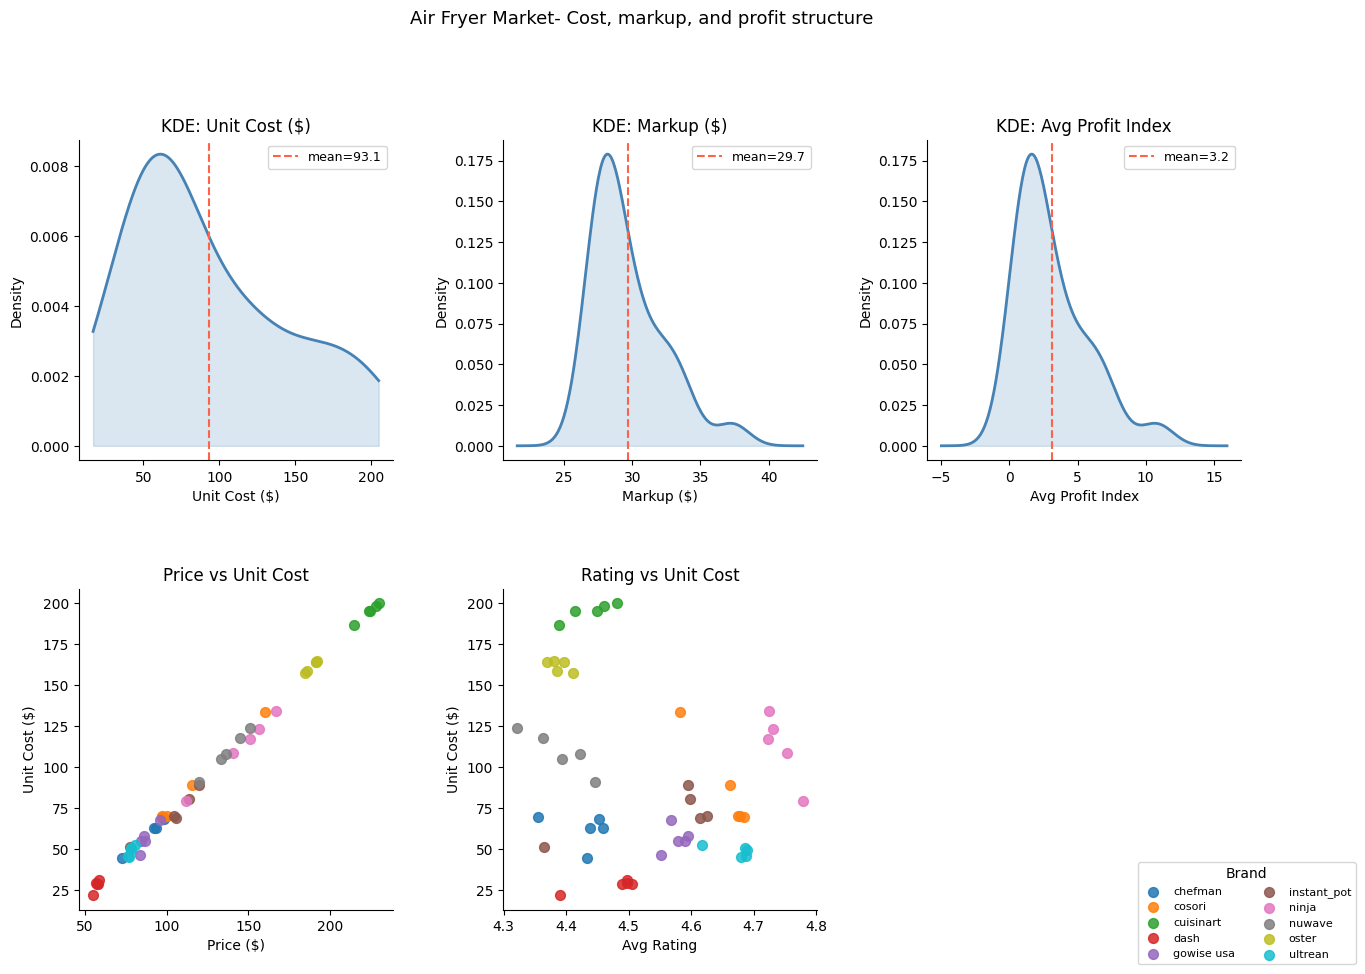

In [13]:
# all my plots
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# kde plots
kde_vars = [('unit_cost', 'Unit Cost ($)'), ('markup', 'Markup ($)'), ('average_profit', 'Avg Profit Index')]

for i, (col, label) in enumerate(kde_vars):
    ax = fig.add_subplot(gs[0, i])
    vals = df[col].dropna().values
    kde = gaussian_kde(vals)
    x = np.linspace(vals.min() - 5, vals.max() + 5, 300)
    ax.plot(x, kde(x), color='steelblue', lw=2)
    ax.fill_between(x, kde(x), alpha=0.2, color='steelblue')
    ax.axvline(vals.mean(), color='tomato', linestyle='--', lw=1.5, label=f'mean={vals.mean():.1f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(f'KDE: {label}')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

# scatter plots
scatter_vars = [
    ('avg_price', 'unit_cost', 'Price ($)', 'Unit Cost ($)', 'Price vs Unit Cost'),
    ('avg_rating', 'unit_cost', 'Avg Rating', 'Unit Cost ($)', 'Rating vs Unit Cost'),
]

for i, (x_col, y_col, x_label, y_label, title) in enumerate(scatter_vars):
    ax = fig.add_subplot(gs[1, i])
    for brand, grp in df.groupby('brand'):
        ax.scatter(grp[x_col], grp[y_col], label=brand, s=50, alpha=0.85)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)

# shared legend for scatter plots
handles, labels = fig.axes[3].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.05),
           fontsize=8, frameon=True, ncol=2, title='Brand')

plt.suptitle('Air Fryer Market- Cost, markup, and profit structure', fontsize=13, y=1.01)
plt.savefig('cost_markup_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# final task
df['profit_foc'] = df['demand_slope'] * df['markup'] + df['brand_share']

df['profit_foc'].head(10)

# output numbers very close to zero, as expected - since we derived unit cost from the same first order condition that we are now checking

0    1.387779e-17
1    1.084202e-19
2    2.775558e-17
3    0.000000e+00
4    0.000000e+00
5   -3.469447e-18
6   -2.775558e-17
7   -6.938894e-18
8   -6.938894e-18
9    6.938894e-18
Name: profit_foc, dtype: float64

## 4. Results

Submit a GitHub repo containing:

1. A short presentation of your findings, about 5-8 slides.
2. The code that created the tables and figures in your presentation.

Your presentation should be written as if you were giving market intelligence to a business audience. It should include:

- A short description of the air-fryer market
- A few plots showing prices, ratings, and market shares over time
- A short explanation of the demand model
- The estimated price coefficient and why its sign matters
- A discussion of the most important product features
- Estimated unit costs, markups, and share-weighted profits
- A conclusion: which brands look strongest, and what would you want to investigate next?

Do not fill slides with raw code. Use your code to produce clear tables and figures, then explain the market story in words.


https://github.com/lainegoldmacher1/air_fryers/blob/main/Demand%20Estimation%20and%20Market%20Analysis_%20Air%20Fryers%20(1).pdf